# Presentation Assets (auto-generated)

This notebook generates **slide-ready PNGs (16:9, white background)** into:
- `artifacts/presentation/`

It reads results from:
- `artifacts/experiments.csv`

Re-run it anytime to refresh visuals after new experiments finish.


In [45]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path('artifacts/presentation')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 16:9 canvas
FIG_W, FIG_H, DPI = 16, 9, 200

# Pastel palette (blue/green)
PALETTE = {
    'blue': '#6FA8DC',
    'green': '#93C47D',
    'teal': '#76A5AF',
    'navy': '#1C4587',
    'gray': '#666666',
    'light_gray': '#E6E6E6',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor': '#DDDDDD',
    'axes.labelcolor': '#222222',
    'text.color': '#222222',
    'axes.titleweight': 'bold',
    'font.size': 14,
})

def show_fig(fig):
    # Display inside the notebook; no files are written.
    plt.show()
    return None

print('Output dir:', OUT_DIR.resolve())
print('Timestamp:', datetime.now().isoformat(timespec='seconds'))


Output dir: /Users/egortatsiy/Projects/CV project/artifacts/presentation
Timestamp: 2026-05-28T08:45:18


## Load results (`artifacts/experiments.csv`)


In [46]:
CSV_PATH = Path('artifacts/experiments.csv')
if CSV_PATH.exists() and CSV_PATH.stat().st_size > 0:
    df = pd.read_csv(CSV_PATH)
    print('Loaded:', CSV_PATH, 'rows=', len(df), 'cols=', len(df.columns))
else:
    df = pd.DataFrame()
    print('No experiments.csv found or empty. Some assets will be generated as placeholders.')

df.head(3)


Loaded: artifacts/experiments.csv rows= 8 cols= 44


,exp_id,exp_name,model_family,model_name,dataset,n_samples,split_train,split_val,split_test,stage1_best_val_acc,...,stage2_train_loss,stage2_val_acc,stage2_val_loss,test_acc,test_loss,train_acc,train_loss,val_acc,val_loss,weight_decay
0,exp01,10k_80-10-10_noaug_baseline,Transfer learning + deep-feature baselines,ResNet50 backbone + custom head,CIFAR-10 (train subset),10000,0.8,0.1,0.1,0.607393,...,0.104111,0.607393,1.425457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,exp02,10k_80-10-10_aug,Transfer learning + deep-feature baselines,ResNet50 backbone + custom head,CIFAR-10 (train subset),10000,0.8,0.1,0.1,0.602398,...,0.784123,0.596404,1.110034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,exp03,20k_80-10-10_noaug,Transfer learning + deep-feature baselines,ResNet50 backbone + custom head,CIFAR-10 (train subset),20000,0.8,0.1,0.1,0.628372,...,0.164073,0.627373,1.301435,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Slide 2: Split pie (50k → 80/10/10)


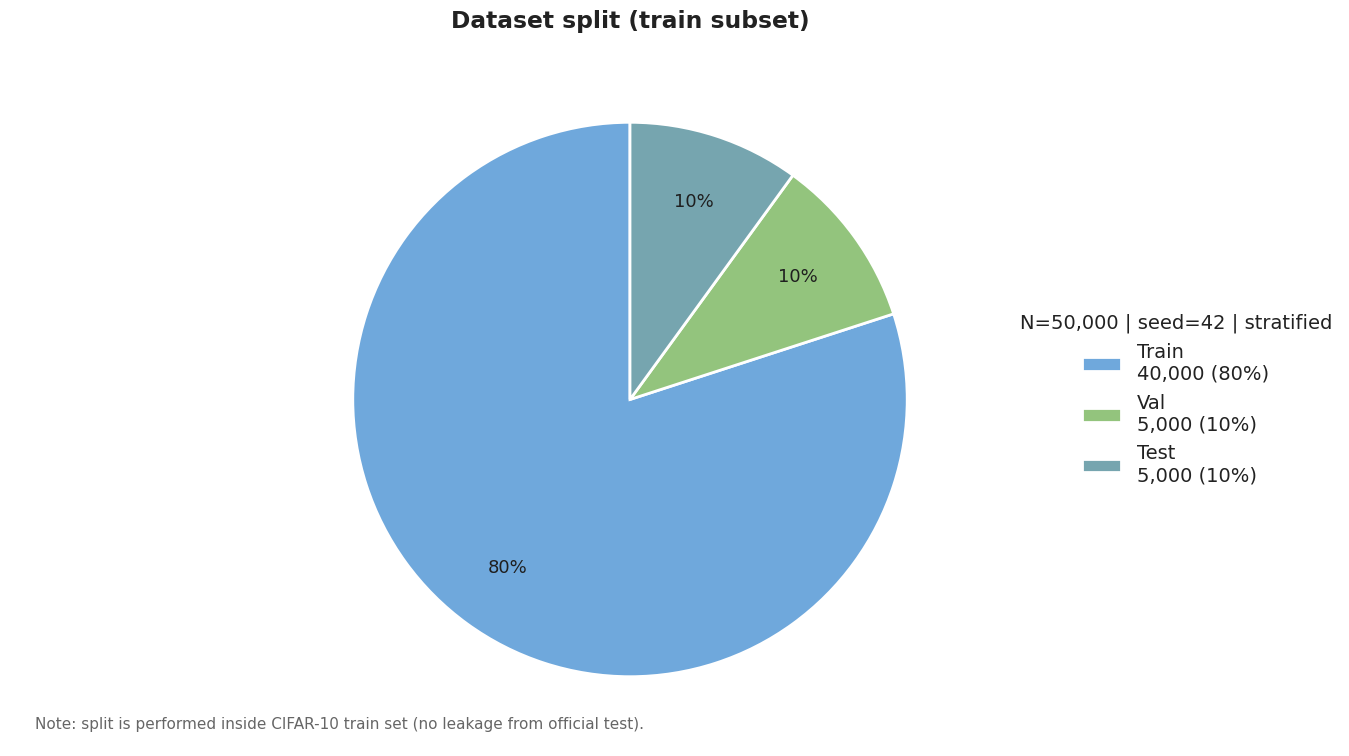

In [47]:
def make_split_pie(n_samples=50_000, train=0.80, val=0.10, test=0.10, seed=42, stratified=True):
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.set_title('Dataset split (train subset)', pad=18)
    ax.axis('equal')

    sizes = [train, val, test]
    labels = [
        f"Train\n{int(n_samples*train):,} ({int(train*100)}%)",
        f"Val\n{int(n_samples*val):,} ({int(val*100)}%)",
        f"Test\n{int(n_samples*test):,} ({int(test*100)}%)",
    ]
    colors = [PALETTE['blue'], PALETTE['green'], PALETTE['teal']]

    wedges, texts, autotexts = ax.pie(
        sizes,
        startangle=90,
        colors=colors,
        wedgeprops=dict(edgecolor='white', linewidth=2),
        autopct=lambda p: f"{p:.0f}%",
        pctdistance=0.75,
    )
    for t in autotexts:
        t.set_color('#1f1f1f')
        t.set_fontsize(13)

    legend_title = f"N={n_samples:,} | seed={seed} | {'stratified' if stratified else 'random'}"
    ax.legend(
        wedges,
        labels,
        title=legend_title,
        loc='center left',
        bbox_to_anchor=(0.80, 0.5),
        frameon=False,
    )

    ax.text(
        0.02,
        0.02,
        'Note: split is performed inside CIFAR-10 train set (no leakage from official test).',
        transform=ax.transAxes,
        fontsize=11,
        color=PALETTE['gray'],
        va='bottom',
    )

    return show_fig(fig)

make_split_pie()


## Slide 3: Pipeline diagram


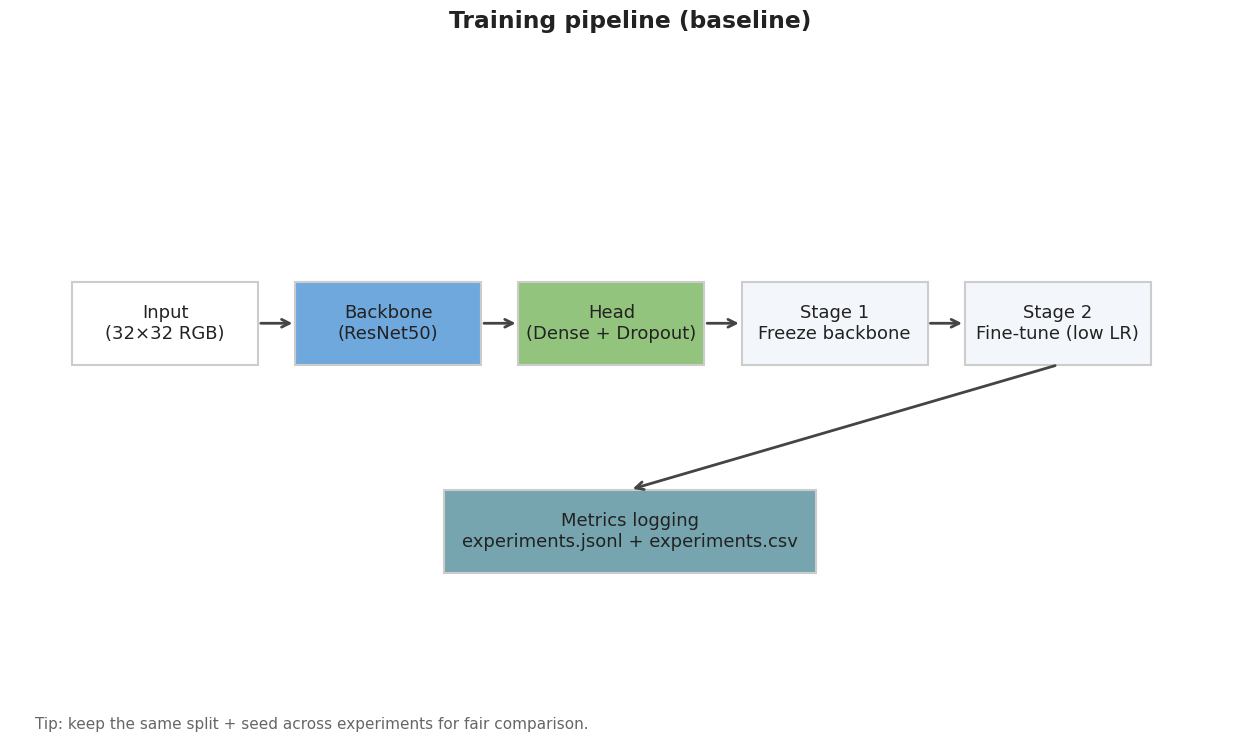

In [48]:
def draw_box(ax, xy, w, h, text, fc, ec='#CCCCCC'):
    x, y = xy
    rect = plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=13)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='#444444'))

def make_pipeline_diagram():
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.set_title('Training pipeline (baseline)', pad=18)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis('off')

    w, h = 15, 12
    y = 55
    xs = [5, 23, 41, 59, 77]

    draw_box(ax, (xs[0], y), w, h, 'Input\n(32×32 RGB)', '#FFFFFF')
    draw_box(ax, (xs[1], y), w, h, 'Backbone\n(ResNet50)', PALETTE['blue'])
    draw_box(ax, (xs[2], y), w, h, 'Head\n(Dense + Dropout)', PALETTE['green'])
    draw_box(ax, (xs[3], y), w, h, 'Stage 1\nFreeze backbone', '#F3F6FA')
    draw_box(ax, (xs[4], y), w, h, 'Stage 2\nFine-tune (low LR)', '#F3F6FA')

    for i in range(len(xs) - 1):
        arrow(ax, xs[i] + w, y + h/2, xs[i+1], y + h/2)

    draw_box(ax, (35, 25), 30, 12, 'Metrics logging\nexperiments.jsonl + experiments.csv', PALETTE['teal'])
    arrow(ax, xs[4] + w/2, y, 50, 37)

    ax.text(0.02, 0.02, 'Tip: keep the same split + seed across experiments for fair comparison.',
            transform=ax.transAxes, fontsize=11, color=PALETTE['gray'], va='bottom')

    return show_fig(fig)

make_pipeline_diagram()


## Slide 4: Generalization gap (real data from `experiments.csv`)


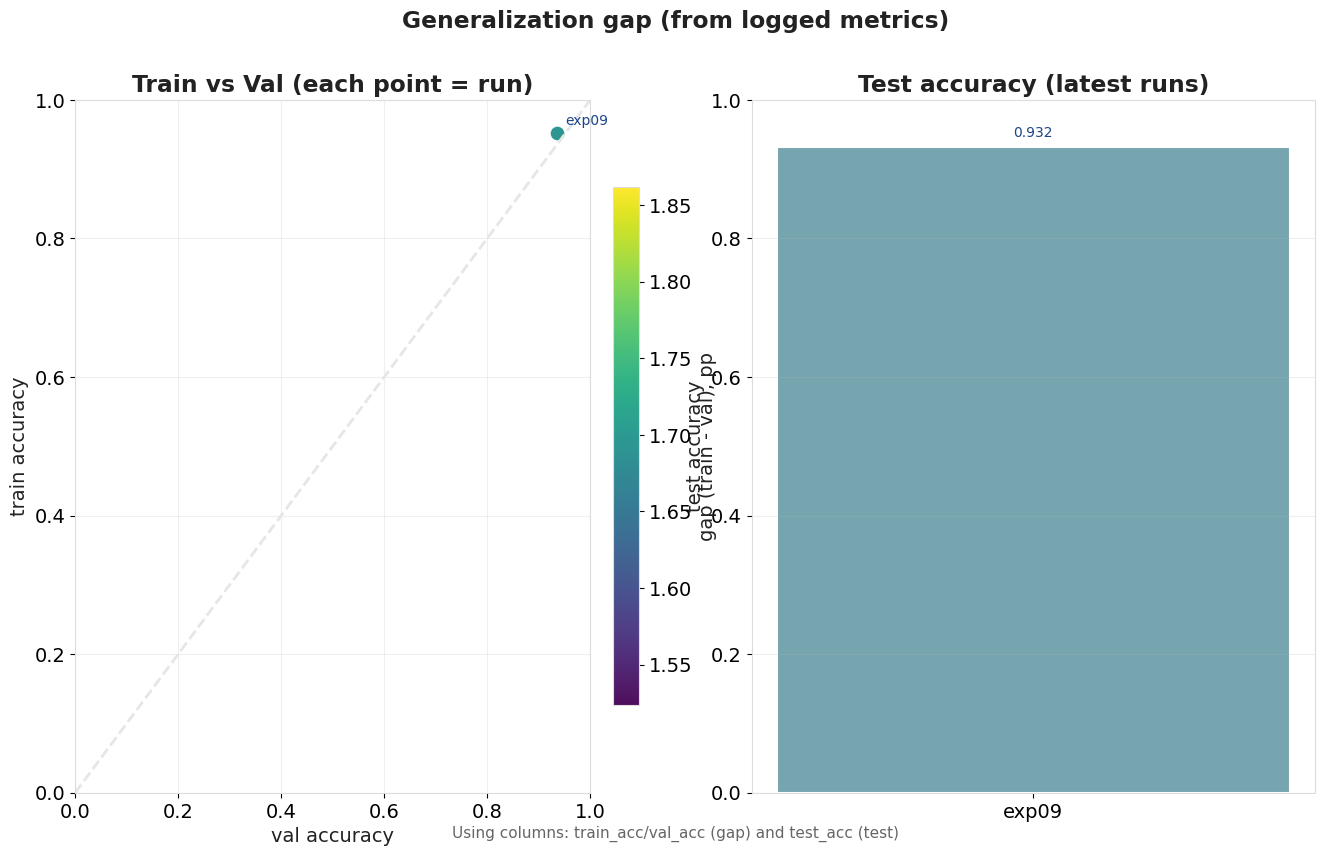

In [49]:
def _first_existing_cols(df, candidates):
    for a, b in candidates:
        if a in df.columns and b in df.columns:
            return a, b
    return None, None

def make_generalization_gap_plots(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))
    fig.suptitle('Generalization gap (from logged metrics)', y=0.98, fontweight='bold')

    if df.empty:
        for ax in axes:
            ax.axis('off')
        axes[0].text(0.5, 0.5, 'No results yet in artifacts/experiments.csv', ha='center', va='center', fontsize=16, color=PALETTE['gray'])
        return show_fig(fig)

    # Pick best available stage for gap visualization
    tr_col, va_col = _first_existing_cols(df, [
        ('train_acc', 'val_acc'),
        ('stage2_train_acc', 'stage2_val_acc'),
        ('stage1_train_acc', 'stage1_val_acc'),
    ])
    if tr_col is None:
        for ax in axes:
            ax.axis('off')
        axes[0].text(0.5, 0.5, 'No train/val accuracy columns found', ha='center', va='center', fontsize=16, color=PALETTE['gray'])
        return show_fig(fig)

    d = df.copy()
    d = d[[c for c in ['exp_id', 'model_name', tr_col, va_col, 'logged_at_utc'] if c in d.columns]].dropna(subset=[tr_col, va_col])
    if 'logged_at_utc' in d.columns:
        d = d.sort_values('logged_at_utc', ascending=False)

    # Keep the most recent runs to avoid clutter
    d = d.head(20)
    d['gap_pp'] = (d[tr_col].astype(float) - d[va_col].astype(float)) * 100.0

    # Plot 1: scatter train vs val
    ax = axes[0]
    ax.set_title('Train vs Val (each point = run)')
    sc = ax.scatter(
        d[va_col].astype(float),
        d[tr_col].astype(float),
        c=d['gap_pp'],
        cmap='viridis',
        s=120,
        edgecolor='white',
        linewidth=1.2,
        alpha=0.95,
    )
    ax.plot([0, 1], [0, 1], linestyle='--', color=PALETTE['light_gray'], linewidth=2)
    ax.set_xlabel('val accuracy')
    ax.set_ylabel('train accuracy')
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.2)
    cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('gap (train - val), pp')

    # Annotate a few points
    for _, r in d.head(5).iterrows():
        label = str(r.get('exp_id', ''))
        ax.annotate(label, (float(r[va_col]), float(r[tr_col])), textcoords='offset points', xytext=(6, 6), fontsize=10, color=PALETTE['navy'])

    # Plot 2: bar test accuracy by run
    te_col, _ = _first_existing_cols(df, [
        ('test_acc', 'val_acc'),
        ('stage2_test_acc', 'stage2_val_acc'),
        ('stage1_test_acc', 'stage1_val_acc'),
    ])
    ax = axes[1]
    ax.set_title('Test accuracy (latest runs)')
    if te_col is None:
        ax.axis('off')
        ax.text(0.5, 0.5, 'No test accuracy column found', ha='center', va='center', fontsize=16, color=PALETTE['gray'])
        return show_fig(fig)

    d2 = df.copy()
    d2 = d2[[c for c in ['exp_id', 'model_name', te_col, 'logged_at_utc'] if c in d2.columns]].dropna(subset=[te_col])
    if 'logged_at_utc' in d2.columns:
        d2 = d2.sort_values('logged_at_utc', ascending=False)
    d2 = d2.head(10)

    xlabels = [str(x) for x in d2.get('exp_id', pd.Series([''] * len(d2))).tolist()]
    vals = d2[te_col].astype(float).tolist()
    ax.bar(range(len(vals)), vals, color=PALETTE['teal'], edgecolor='white', linewidth=1.5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(xlabels, rotation=0)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel('test accuracy')
    ax.grid(True, axis='y', alpha=0.2)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, color=PALETTE['navy'])

    fig.text(0.5, 0.06, f"Using columns: {tr_col}/{va_col} (gap) and {te_col} (test)", ha='center', fontsize=11, color=PALETTE['gray'])
    return show_fig(fig)

make_generalization_gap_plots(df)


## Optional visuals: 5 alternative ways to show overfitting / generalization gap (real data)

Pick the one that best fits your storytelling.


In [50]:
def get_cols_for_triplet(df: pd.DataFrame):
    # Prefer stage2 (final) if present; else stage1; else new notebook keys.
    for prefix in ['stage2_', 'stage1_']:
        tr, va, te = prefix + 'train_acc', prefix + 'val_acc', prefix + 'test_acc'
        if tr in df.columns and va in df.columns and te in df.columns:
            return tr, va, te
    # New notebook naming
    if {'train_acc', 'val_acc', 'test_acc'}.issubset(df.columns):
        return 'train_acc', 'val_acc', 'test_acc'
    return None, None, None

def recent_runs(df: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    if df.empty:
        return df
    d = df.copy()
    if 'logged_at_utc' in d.columns:
        d = d.sort_values('logged_at_utc', ascending=False)
    return d.head(n)

def _short(s, n):
    s = '' if s is None else str(s)
    return s if len(s) <= n else (s[: n - 1] + '…')

trip_tr, trip_va, trip_te = get_cols_for_triplet(df)
print('Using acc columns:', trip_tr, trip_va, trip_te)


Using acc columns: stage2_train_acc stage2_val_acc stage2_test_acc


### A) Slope/Dumbbell chart: train → val → test per experiment


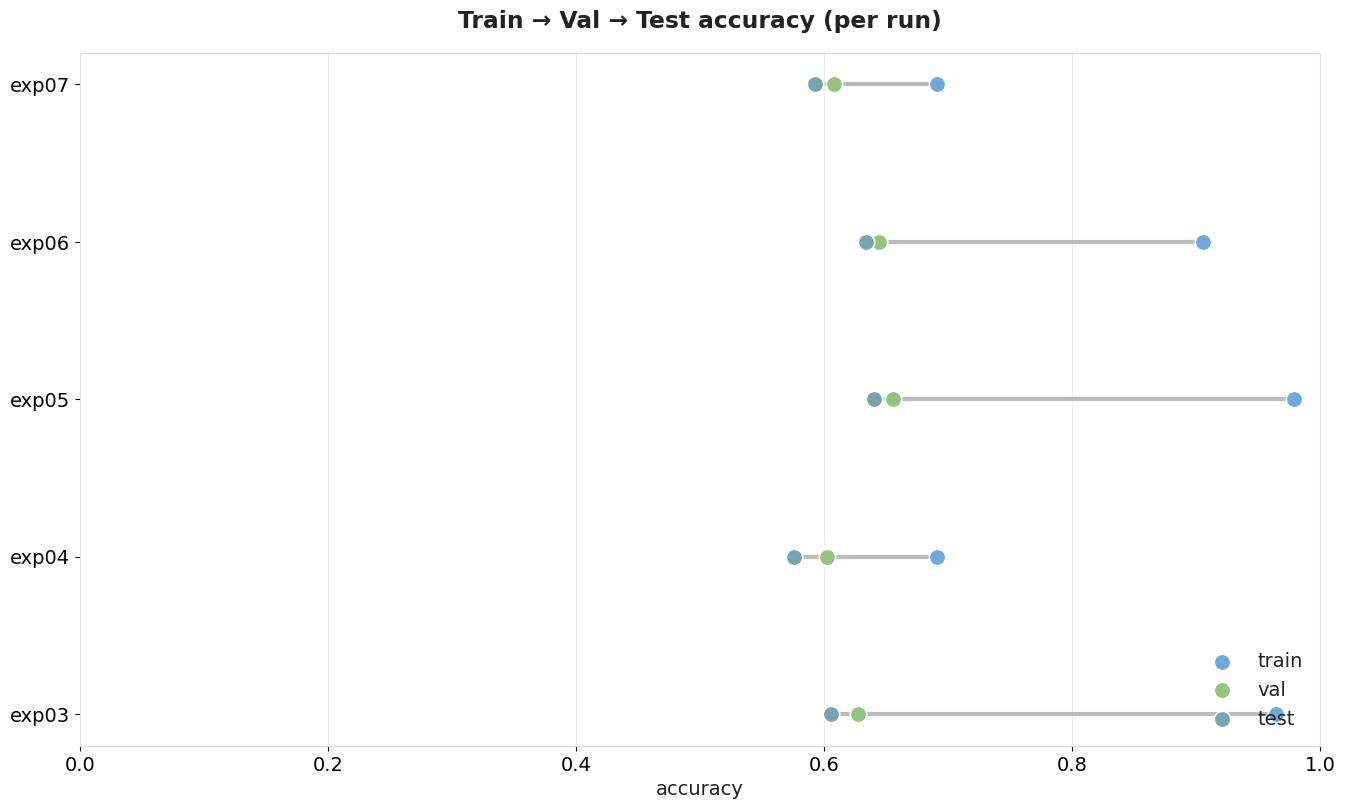

In [51]:
def viz_slope_train_val_test(df: pd.DataFrame, n: int = 6):
    if df.empty or trip_tr is None:
        print('No data/columns for this visual.')
        return
    d = recent_runs(df, n=n).dropna(subset=[trip_tr, trip_va, trip_te]).copy()
    if d.empty:
        print('No complete rows found.')
        return

    labels = [str(x) for x in d.get('exp_id', range(len(d))).tolist()]
    y = np.arange(len(d))[::-1]
    tr = d[trip_tr].astype(float).to_numpy()
    va = d[trip_va].astype(float).to_numpy()
    te = d[trip_te].astype(float).to_numpy()

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.set_title('Train → Val → Test accuracy (per run)', pad=18)

    for i in range(len(d)):
        ax.plot([tr[i], va[i], te[i]], [y[i], y[i], y[i]], color='#BBBBBB', lw=3, zorder=1)
    ax.scatter(tr, y, s=140, color=PALETTE['blue'], edgecolor='white', linewidth=1.2, label='train', zorder=3)
    ax.scatter(va, y, s=140, color=PALETTE['green'], edgecolor='white', linewidth=1.2, label='val', zorder=3)
    ax.scatter(te, y, s=140, color=PALETTE['teal'], edgecolor='white', linewidth=1.2, label='test', zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel('accuracy')
    ax.grid(True, axis='x', alpha=0.2)
    ax.legend(frameon=False, loc='lower right')
    show_fig(fig)

viz_slope_train_val_test(df, n=6)


### B) Grouped bars: train / val / test per experiment


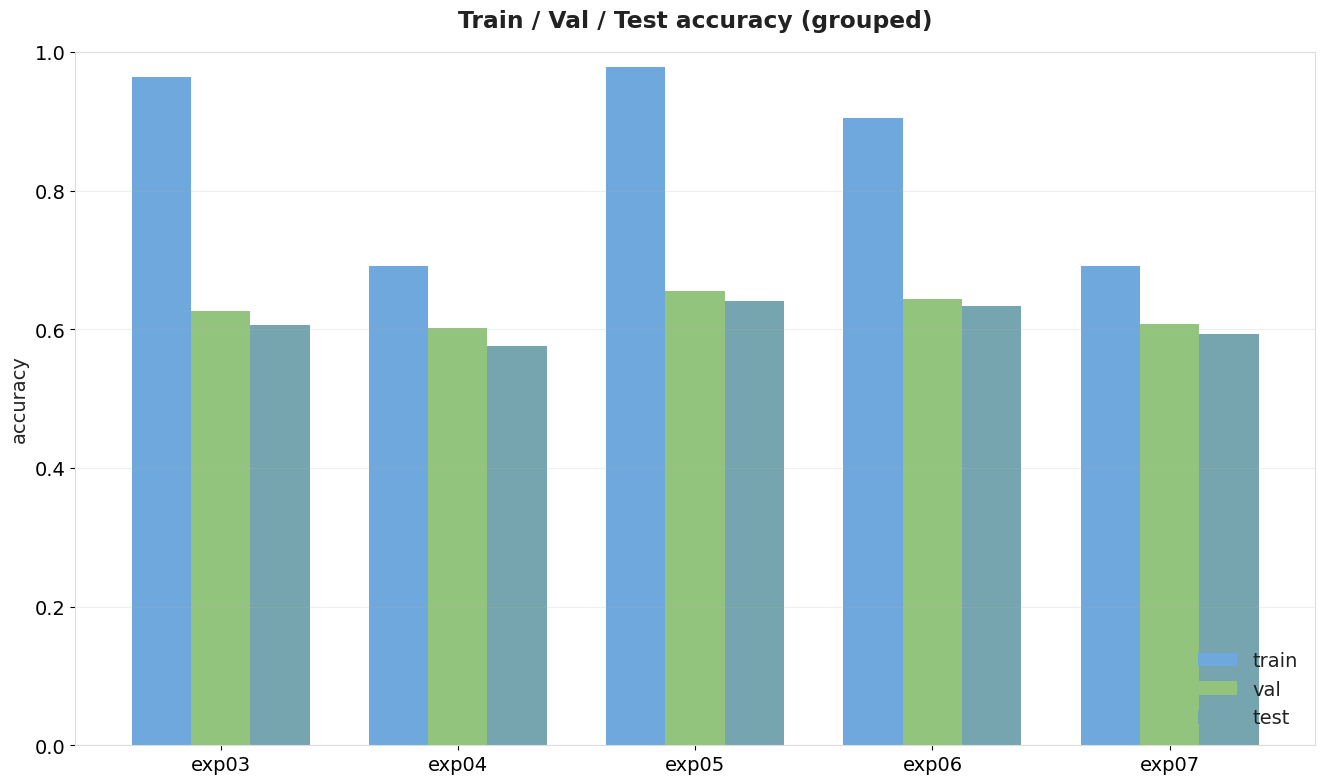

In [52]:
def viz_grouped_bars(df: pd.DataFrame, n: int = 6):
    if df.empty or trip_tr is None:
        print('No data/columns for this visual.')
        return
    d = recent_runs(df, n=n).dropna(subset=[trip_tr, trip_va, trip_te]).copy()
    if d.empty:
        print('No complete rows found.')
        return

    labels = [str(x) for x in d.get('exp_id', range(len(d))).tolist()][::-1]
    tr = d[trip_tr].astype(float).to_numpy()[::-1]
    va = d[trip_va].astype(float).to_numpy()[::-1]
    te = d[trip_te].astype(float).to_numpy()[::-1]

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.set_title('Train / Val / Test accuracy (grouped)', pad=18)
    ax.bar(x - width, tr, width, label='train', color=PALETTE['blue'])
    ax.bar(x, va, width, label='val', color=PALETTE['green'])
    ax.bar(x + width, te, width, label='test', color=PALETTE['teal'])

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel('accuracy')
    ax.grid(True, axis='y', alpha=0.2)
    ax.legend(frameon=False, loc='lower right')
    show_fig(fig)

viz_grouped_bars(df, n=6)


### C) Gap-only: (train − val) and (train − test) in percentage points


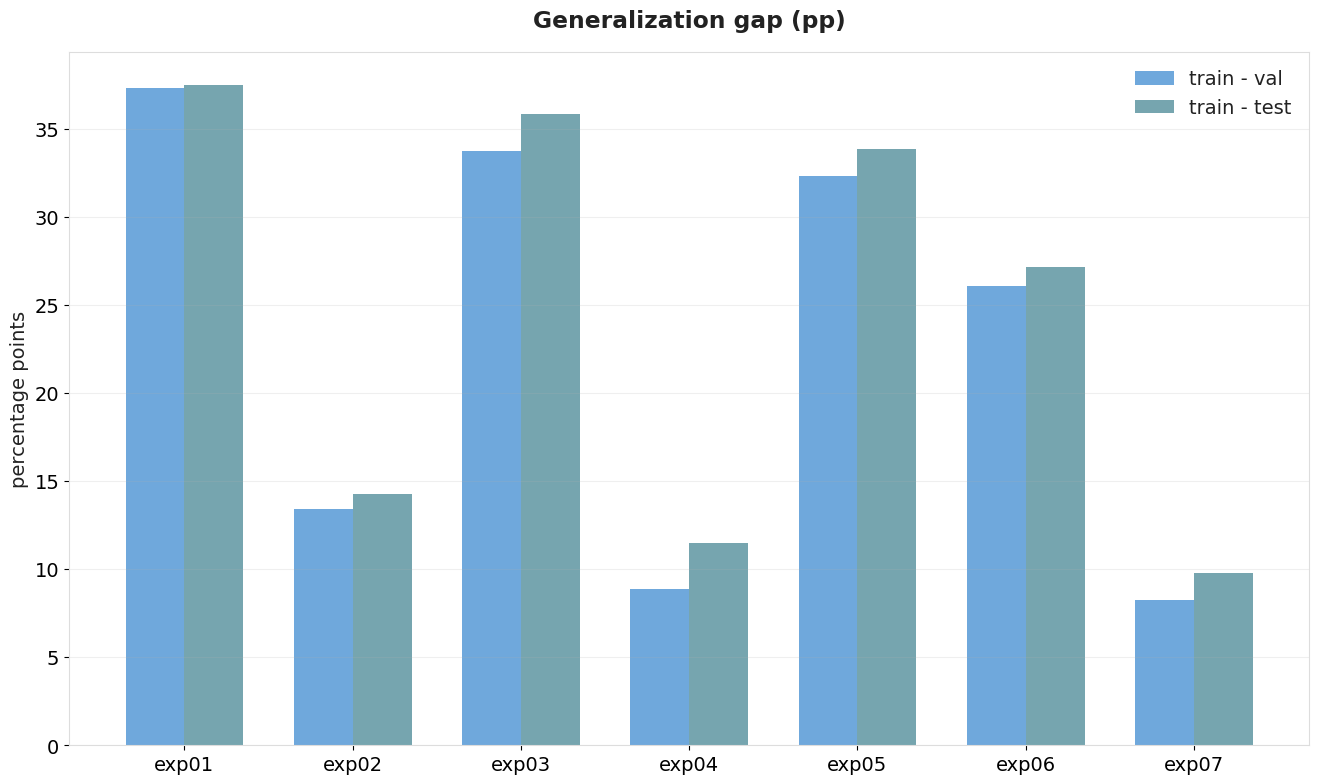

In [53]:
def viz_gap_only(df: pd.DataFrame, n: int = 8):
    if df.empty or trip_tr is None:
        print('No data/columns for this visual.')
        return
    d = recent_runs(df, n=n).dropna(subset=[trip_tr, trip_va, trip_te]).copy()
    if d.empty:
        print('No complete rows found.')
        return

    labels = [str(x) for x in d.get('exp_id', range(len(d))).tolist()][::-1]
    gap_tv = (d[trip_tr].astype(float) - d[trip_va].astype(float)).to_numpy()[::-1] * 100.0
    gap_tt = (d[trip_tr].astype(float) - d[trip_te].astype(float)).to_numpy()[::-1] * 100.0

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.set_title('Generalization gap (pp)', pad=18)
    ax.bar(x - width/2, gap_tv, width, label='train - val', color=PALETTE['blue'])
    ax.bar(x + width/2, gap_tt, width, label='train - test', color=PALETTE['teal'])
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('percentage points')
    ax.grid(True, axis='y', alpha=0.2)
    ax.legend(frameon=False, loc='upper right')
    show_fig(fig)

viz_gap_only(df, n=8)


### D) Trade-off scatter: gap (train−val) vs test accuracy


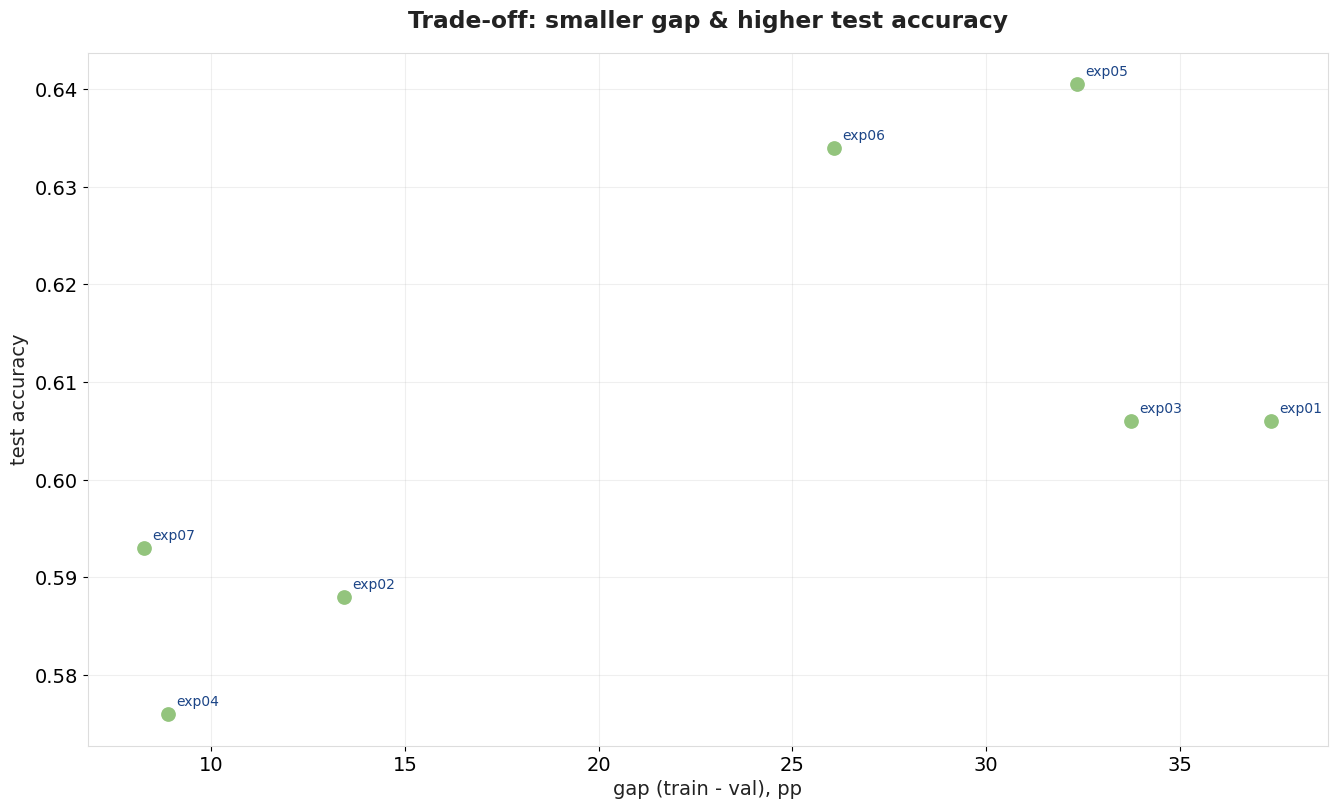

In [54]:
def viz_gap_vs_test(df: pd.DataFrame, n: int = 20):
    if df.empty or trip_tr is None:
        print('No data/columns for this visual.')
        return
    d = recent_runs(df, n=n).dropna(subset=[trip_tr, trip_va, trip_te]).copy()
    if d.empty:
        print('No complete rows found.')
        return

    gap = (d[trip_tr].astype(float) - d[trip_va].astype(float)) * 100.0
    test = d[trip_te].astype(float)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.set_title('Trade-off: smaller gap & higher test accuracy', pad=18)
    ax.scatter(gap, test, s=140, color=PALETTE['green'], edgecolor='white', linewidth=1.2)
    ax.set_xlabel('gap (train - val), pp')
    ax.set_ylabel('test accuracy')
    ax.grid(True, alpha=0.2)

    for _, r in d.head(8).iterrows():
        ax.annotate(str(r.get('exp_id', '')), (float((r[trip_tr]-r[trip_va])*100.0), float(r[trip_te])), textcoords='offset points', xytext=(6, 6), fontsize=10, color=PALETTE['navy'])
    show_fig(fig)

viz_gap_vs_test(df, n=20)


### E) Small multiples: per-run mini bars (train/val/test)


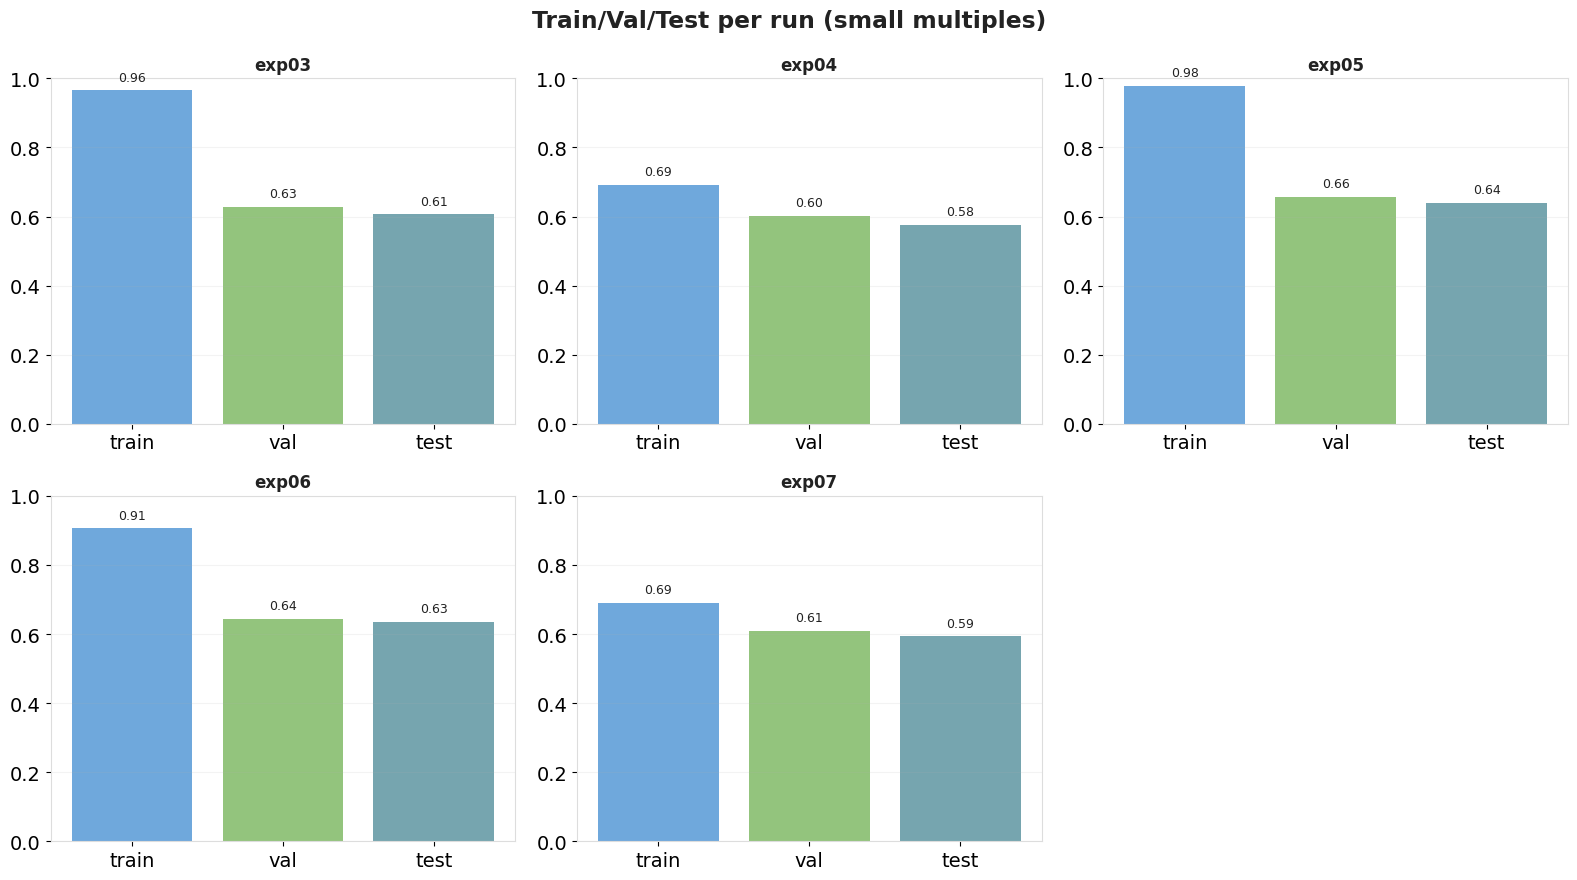

In [55]:
def viz_small_multiples(df: pd.DataFrame, n: int = 6):
    if df.empty or trip_tr is None:
        print('No data/columns for this visual.')
        return
    d = recent_runs(df, n=n).dropna(subset=[trip_tr, trip_va, trip_te]).copy()
    if d.empty:
        print('No complete rows found.')
        return
    d = d.iloc[::-1].reset_index(drop=True)

    cols = 3
    rows = int(np.ceil(len(d) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(FIG_W, FIG_H))
    fig.suptitle('Train/Val/Test per run (small multiples)', y=0.98, fontweight='bold')
    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):
        if i >= len(d):
            ax.axis('off')
            continue
        r = d.iloc[i]
        vals = [float(r[trip_tr]), float(r[trip_va]), float(r[trip_te])]
        ax.bar(['train', 'val', 'test'], vals, color=[PALETTE['blue'], PALETTE['green'], PALETTE['teal']])
        ax.set_ylim(0.0, 1.0)
        ax.set_title(_short(r.get('exp_id', f'run{i}'), 20), fontsize=12)
        ax.grid(True, axis='y', alpha=0.15)
        for j, v in enumerate(vals):
            ax.text(j, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    show_fig(fig)

viz_small_multiples(df, n=6)


## Optional table: model reference (for an early slide)


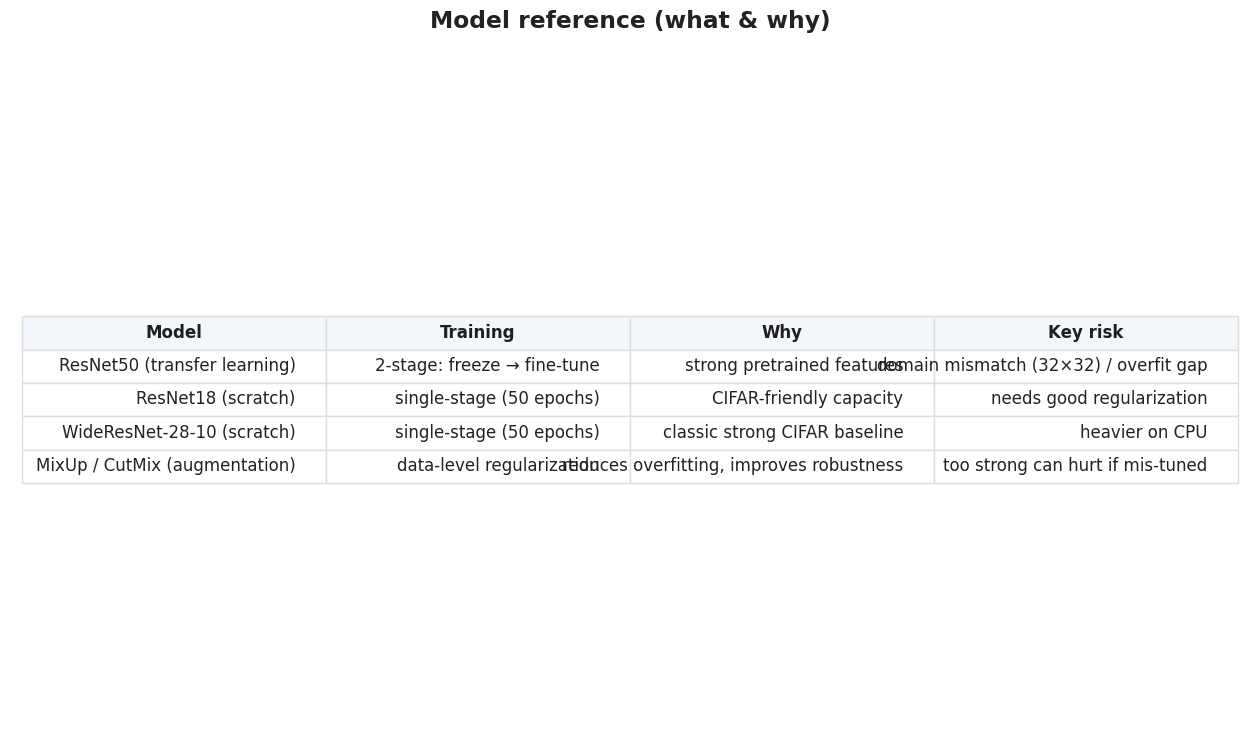

In [56]:
def make_model_reference_table():
    ref = pd.DataFrame([
        {
            'Model': 'ResNet50 (transfer learning)',
            'Training': '2-stage: freeze → fine-tune',
            'Why': 'strong pretrained features',
            'Key risk': 'domain mismatch (32×32) / overfit gap',
        },
        {
            'Model': 'ResNet18 (scratch)',
            'Training': 'single-stage (50 epochs)',
            'Why': 'CIFAR-friendly capacity',
            'Key risk': 'needs good regularization',
        },
        {
            'Model': 'WideResNet-28-10 (scratch)',
            'Training': 'single-stage (50 epochs)',
            'Why': 'classic strong CIFAR baseline',
            'Key risk': 'heavier on CPU',
        },
        {
            'Model': 'MixUp / CutMix (augmentation)',
            'Training': 'data-level regularization',
            'Why': 'reduces overfitting, improves robustness',
            'Key risk': 'too strong can hurt if mis-tuned',
        },
    ])

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.axis('off')
    ax.set_title('Model reference (what & why)', pad=18)
    table = ax.table(cellText=ref.values.tolist(), colLabels=ref.columns.tolist(), loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(0.98, 2.0)
    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor('#DDDDDD')
        if r == 0:
            cell.set_text_props(weight='bold', color='#1f1f1f')
            cell.set_facecolor('#F3F6FA')
        else:
            cell.set_facecolor('white')
    show_fig(fig)

make_model_reference_table()


## Slide 5: Experiment plan table (new direction)


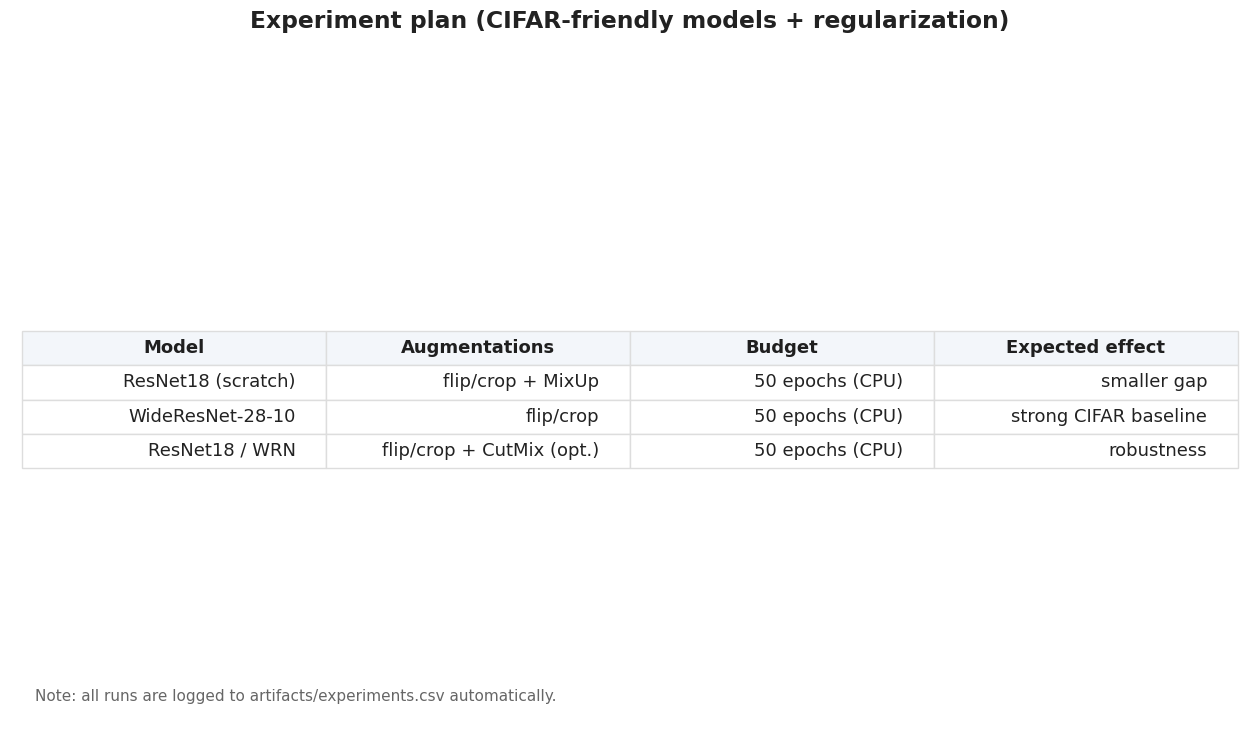

In [57]:
def make_plan_table():
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.axis('off')
    ax.set_title('Experiment plan (CIFAR-friendly models + regularization)', pad=18)

    cols = ['Model', 'Augmentations', 'Budget', 'Expected effect']
    rows = [
        ['ResNet18 (scratch)', 'flip/crop + MixUp', '50 epochs (CPU)', 'smaller gap'],
        ['WideResNet-28-10', 'flip/crop', '50 epochs (CPU)', 'strong CIFAR baseline'],
        ['ResNet18 / WRN', 'flip/crop + CutMix (opt.)', '50 epochs (CPU)', 'robustness'],
    ]

    table = ax.table(cellText=rows, colLabels=cols, loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(13)
    table.scale(0.98, 2.05)

    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor('#DDDDDD')
        if r == 0:
            cell.set_text_props(weight='bold', color='#1f1f1f')
            cell.set_facecolor('#F3F6FA')
        else:
            cell.set_facecolor('white')

    ax.text(0.02, 0.06, 'Note: all runs are logged to artifacts/experiments.csv automatically.',
            transform=ax.transAxes, fontsize=11, color=PALETTE['gray'], va='bottom')

    return show_fig(fig)

make_plan_table()


## Slide 6: Results summary table (auto from `experiments.csv`)


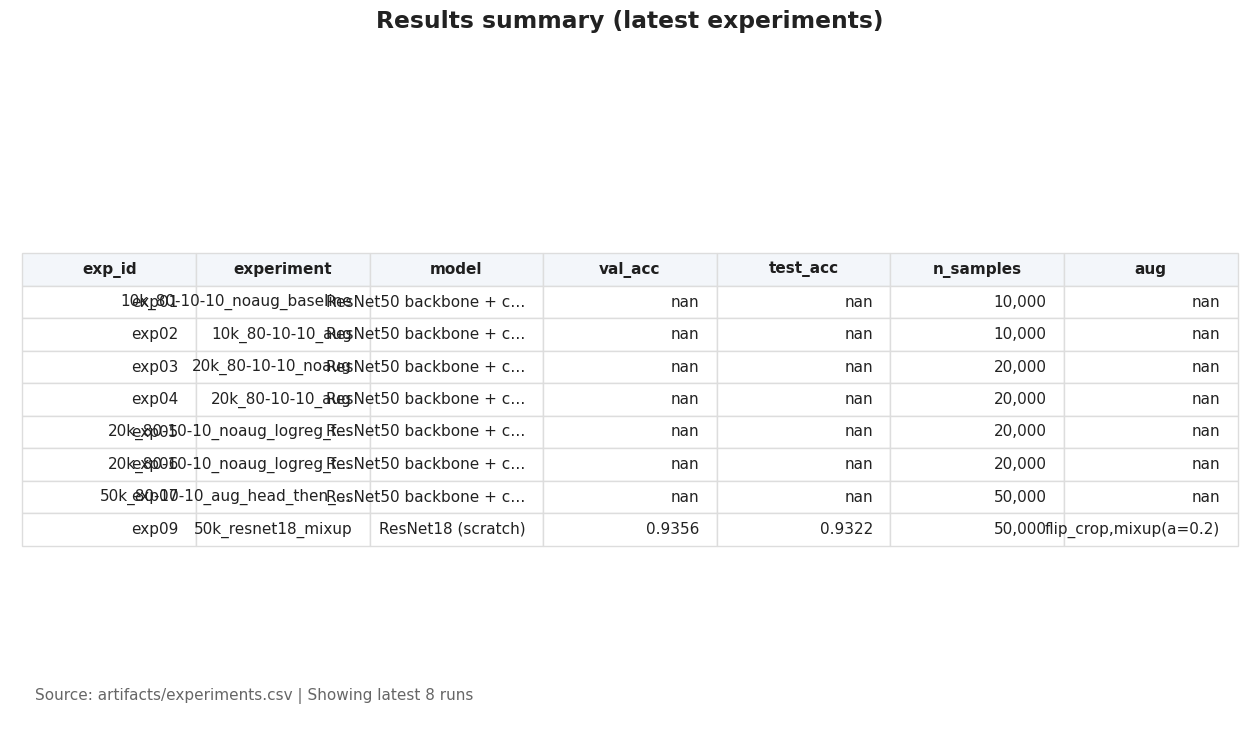

In [58]:
def pick_acc_cols(df: pd.DataFrame):
    candidates = [
        ('val_acc', 'test_acc'),
        ('stage2_val_acc', 'stage2_test_acc'),
        ('stage1_val_acc', 'stage1_test_acc'),
    ]
    for v, t in candidates:
        if v in df.columns and t in df.columns:
            return v, t
    return None, None

def make_results_table(df: pd.DataFrame, top_n: int = 8):
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.axis('off')
    ax.set_title('Results summary (latest experiments)', pad=18)

    if df.empty:
        ax.text(0.5, 0.5, 'No results yet. Run experiments to populate artifacts/experiments.csv',
                ha='center', va='center', fontsize=16, color=PALETTE['gray'])
        return show_fig(fig)

    vcol, tcol = pick_acc_cols(df)
    if vcol is None:
        ax.text(0.5, 0.5, 'No recognizable accuracy columns found in experiments.csv',
                ha='center', va='center', fontsize=16, color=PALETTE['gray'])
        return show_fig(fig)

    # Keep slide table compact: drop timestamps by default
    # Keep only the fields that fit well on a slide
    cols_present = [c for c in ['exp_id', 'exp_name', 'model_name', vcol, tcol, 'n_samples', 'augmentations'] if c in df.columns]
    d = df[cols_present].copy()
    if 'logged_at_utc' in d.columns:
        d = d.sort_values('logged_at_utc', ascending=False)

    def fmt_acc(x):
        try:
            return f"{float(x):.4f}"
        except Exception:
            return ''

    d[vcol] = d[vcol].apply(fmt_acc)
    d[tcol] = d[tcol].apply(fmt_acc)
    if 'n_samples' in d.columns:
        def _fmt_ns(x):
            try:
                return f"{int(float(x)):,}"
            except Exception:
                return str(x)
        d['n_samples'] = d['n_samples'].apply(_fmt_ns)

    d = d.head(top_n)

    rename = {
        vcol: 'val_acc',
        tcol: 'test_acc',
        'model_name': 'model',
        'exp_name': 'experiment',
        'augmentations': 'aug',
        # no timestamps on slide
    }
    d = d.rename(columns={k: v for k, v in rename.items() if k in d.columns})

    # Shorten long strings so the table doesn't overlap
    def shorten(s, max_len):
        s = '' if s is None else str(s)
        return s if len(s) <= max_len else (s[: max_len - 1] + '…')

    if 'experiment' in d.columns:
        d['experiment'] = d['experiment'].apply(lambda s: shorten(s, 28))
    if 'model' in d.columns:
        d['model'] = d['model'].apply(lambda s: shorten(s, 22))
    if 'aug' in d.columns:
        d['aug'] = d['aug'].apply(lambda s: shorten(s, 24))

    table = ax.table(cellText=d.values.tolist(), colLabels=d.columns.tolist(), loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(0.98, 1.95)

    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor('#DDDDDD')
        if r == 0:
            cell.set_text_props(weight='bold', color='#1f1f1f')
            cell.set_facecolor('#F3F6FA')
        else:
            cell.set_facecolor('white')

    ax.text(0.02, 0.06, f"Source: {CSV_PATH} | Showing latest {len(d)} runs", transform=ax.transAxes,
            fontsize=11, color=PALETTE['gray'], va='bottom')

    return show_fig(fig)

make_results_table(df, top_n=8)


## Presentation summary: final model card (one slide)

A slide-friendly, large-block summary for the **latest** (or selected) model.


In [59]:
def _as_float(x):
    try:
        if pd.isna(x):
            return None
        return float(x)
    except Exception:
        return None

def pick_latest_run(df: pd.DataFrame, prefer_exp_id: str | None = None) -> dict:
    if df.empty:
        return {}
    d = df.copy()
    if prefer_exp_id is not None and 'exp_id' in d.columns:
        dd = d[d['exp_id'].astype(str) == str(prefer_exp_id)].copy()
        if not dd.empty:
            d = dd
    if 'logged_at_utc' in d.columns:
        d = d.sort_values('logged_at_utc', ascending=False)
    return d.iloc[0].to_dict()

latest = pick_latest_run(df, prefer_exp_id=None)
latest


{'exp_id': 'exp09',
 'exp_name': '50k_resnet18_mixup',
 'model_family': 'Scratch CNN + modern aug',
 'model_name': 'ResNet18 (scratch)',
 'dataset': 'CIFAR-10 (train full)',
 'n_samples': 50000,
 'split_train': 0.8,
 'split_val': 0.1,
 'split_test': 0.1,
 'stage1_best_val_acc': nan,
 'stage1_test_acc': nan,
 'stage2_best_val_acc': nan,
 'stage2_test_acc': nan,
 'notes': nan,
 'logged_at_utc': '2026-05-28T06:21:36+00:00',
 'augmentations': 'flip_crop,mixup(a=0.2)',
 'baseline_catboost_test_acc': nan,
 'baseline_logreg_test_acc': nan,
 'batch_size': 50.0,
 'best_val_acc': 0.9355999827384948,
 'epochs': 50.0,
 'lr': 0.001,
 'random_state': 42,
 'stage1_gap_train_test_pp': nan,
 'stage1_gap_train_val_pp': nan,
 'stage1_test_loss': nan,
 'stage1_train_acc': nan,
 'stage1_train_loss': nan,
 'stage1_val_acc': nan,
 'stage1_val_loss': nan,
 'stage2_gap_train_test_pp': nan,
 'stage2_gap_train_val_pp': nan,
 'stage2_test_loss': nan,
 'stage2_train_acc': nan,
 'stage2_train_loss': nan,
 'stage2_v

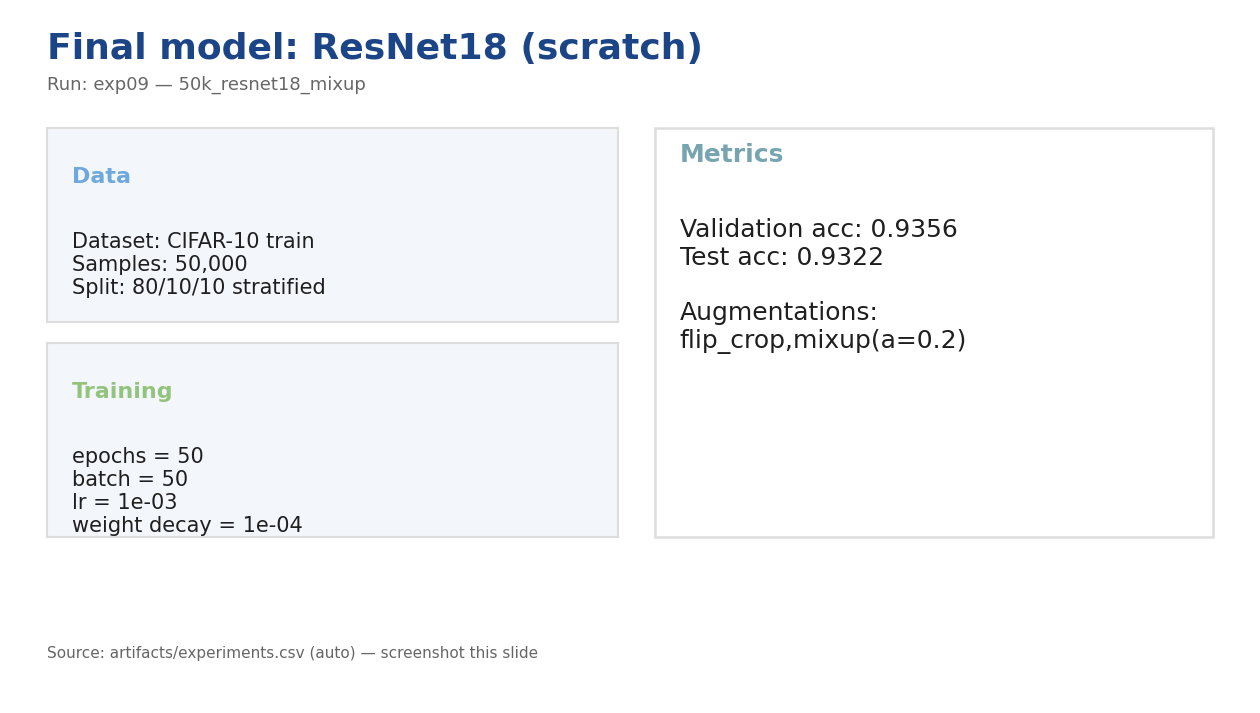

In [60]:
def best_val_test_from_row(r: dict):
    # Prefer NewModels metrics if present
    val = _as_float(r.get('val_acc'))
    test = _as_float(r.get('test_acc'))
    # Fallback to stage2
    if val is None:
        val = _as_float(r.get('stage2_val_acc'))
    if test is None:
        test = _as_float(r.get('stage2_test_acc'))
    # Fallback to stage1
    if val is None:
        val = _as_float(r.get('stage1_val_acc'))
    if test is None:
        test = _as_float(r.get('stage1_test_acc'))
    return val, test

def make_final_model_card(r: dict):
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.axis('off')

    if not r:
        ax.text(0.5, 0.5, 'No runs found in artifacts/experiments.csv', ha='center', va='center', fontsize=18, color=PALETTE['gray'])
        return show_fig(fig)

    exp_id = str(r.get('exp_id', '')).strip()
    exp_name = str(r.get('exp_name', exp_id)).strip()
    model = str(r.get('model_name', '')).strip()
    n = r.get('n_samples', '')
    try:
        n_fmt = f"{int(float(n)):,}" if str(n).strip() not in ['', 'nan'] else '—'
    except Exception:
        n_fmt = '—'

    epochs = r.get('epochs', None)
    bs = r.get('batch_size', None)
    lr = r.get('lr', None)
    wd = r.get('weight_decay', None)
    aug = r.get('augmentations', '—')
    val, test = best_val_test_from_row(r)

    title = f"Final model: {model}"
    ax.text(0.03, 0.93, title, fontsize=26, fontweight='bold', color=PALETTE['navy'], transform=ax.transAxes)
    ax.text(0.03, 0.885, f"Run: {exp_id} — {_short(exp_name, 60)}", fontsize=13, color=PALETTE['gray'], transform=ax.transAxes)

    def box(x, y, w, h, header, body, color_key):
        rect = plt.Rectangle((x, y), w, h, facecolor='#F3F6FA', edgecolor='#DDDDDD', linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x + 0.02, y + h - 0.08, header, fontsize=16, fontweight='bold', color=PALETTE[color_key])
        ax.text(x + 0.02, y + h - 0.15, body, fontsize=15, color='#1f1f1f', va='top')

    # Left column
    data_body = f"Dataset: CIFAR-10 train\nSamples: {n_fmt}\nSplit: 80/10/10 stratified"
    train_parts = []
    if epochs is not None and str(epochs).strip() not in ['', 'nan']:
        train_parts.append(f"epochs = {int(float(epochs))}")
    if bs is not None and str(bs).strip() not in ['', 'nan']:
        train_parts.append(f"batch = {int(float(bs))}")
    if lr is not None and str(lr).strip() not in ['', 'nan']:
        try:
            train_parts.append(f"lr = {float(lr):.0e}")
        except Exception:
            train_parts.append(f"lr = {lr}")
    if wd is not None and str(wd).strip() not in ['', 'nan']:
        try:
            train_parts.append(f"weight decay = {float(wd):.0e}")
        except Exception:
            train_parts.append(f"weight decay = {wd}")
    training_body = "\n".join(train_parts) if train_parts else '—'
    aug_body = str(aug) if str(aug).strip() not in ['', 'nan'] else '—'

    box(0.03, 0.55, 0.46, 0.28, 'Data', data_body, 'blue')
    box(0.03, 0.24, 0.46, 0.28, 'Training', training_body, 'green')

    # Right column: metrics big
    metric_lines = []
    metric_lines.append(f"Validation acc: {val:.4f}" if val is not None else "Validation acc: —")
    metric_lines.append(f"Test acc: {test:.4f}" if test is not None else "Test acc: —")
    metric_lines.append('')
    metric_lines.append('Augmentations:')
    metric_lines.append(_short(aug_body, 120))
    metrics_body = "\n".join(metric_lines)
    rect = plt.Rectangle((0.52, 0.24), 0.45, 0.59, facecolor='white', edgecolor='#DDDDDD', linewidth=1.8)
    ax.add_patch(rect)
    ax.text(0.54, 0.78, 'Metrics', fontsize=18, fontweight='bold', color=PALETTE['teal'])
    ax.text(0.54, 0.70, metrics_body, fontsize=18, color='#1f1f1f', va='top')

    ax.text(0.03, 0.06, 'Source: artifacts/experiments.csv (auto) — screenshot this slide', transform=ax.transAxes, fontsize=11, color=PALETTE['gray'], va='bottom')
    return show_fig(fig)

make_final_model_card(latest)
